<a href="https://colab.research.google.com/github/sachini86/MyResearch/blob/main/seperatemodels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After running this cell, click the link,
# sign in to your Google account, copy the code, paste it here
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


In [ ]:
# Install Kaggle API
!pip install -q kaggle

# Upload your kaggle.json API key
from google.colab import files
files.upload()  # ← click this, select your kaggle.json file

# Move it to the right place
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d kaveendahelitha40/cinnamon-quill-grades-classification-image-dataset
!unzip -q cinnamon-quill-grades-classification-image-dataset.zip -d /content/kaggle_dataset

# Check what was downloaded
import os
for item in os.listdir('/content/kaggle_dataset'):
    print(item)

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kaveendahelitha40/cinnamon-quill-grades-classification-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 5.52G/5.52G [01:21<00:00, 72.6MB/s]

cinnamon quills images


In [ ]:
import os

# See what's inside
for root, dirs, files in os.walk('/content/kaggle_dataset'):
    level = root.replace('/content/kaggle_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show 2 levels deep
        for f in files[:3]:  # show first 3 files as sample
            print(f'{indent}  {f}')

kaggle_dataset/
  cinnamon quills images/
    C5/
    C5 Special/
    C4/
    Alba/


In [ ]:
import os
import shutil

YOUR_DATA   = '/content/drive/MyDrive'
KAGGLE_DATA = '/content/kaggle_dataset/cinnamon quills images'

CLASSES_YOUR     = ['Alba', 'C4', 'C5', 'C5-special']
CLASSES_KAGGLE   = ['Alba', 'C4', 'C5', 'C5 Special']
CLASSES_STANDARD = ['alba', 'c4', 'c5', 'c5_special']

WORK_DIR    = '/content/cinnamon_work'
MERGED_DATA = '/content/cinnamon_work/merged_dataset'
SPLIT_DATA  = '/content/cinnamon_work/split_dataset'
os.makedirs(WORK_DIR, exist_ok=True)

def count_images_recursive(folder):
    """Counts all images in folder AND all subfolders"""
    count = 0
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                count += 1
    return count

# Verify counts
for yours, kaggle in zip(CLASSES_YOUR, CLASSES_KAGGLE):
    p1 = os.path.join(YOUR_DATA, yours)
    p2 = os.path.join(KAGGLE_DATA, kaggle)
    c1 = count_images_recursive(p1) if os.path.exists(p1) else 0
    c2 = count_images_recursive(p2) if os.path.exists(p2) else 0
    print(f'{yours:12s} → yours: {c1:4d}  kaggle: {c2:4d}  total: {c1+c2:4d}')

Alba         → yours:  250  kaggle:  173  total:  423
C4           → yours:   95  kaggle:  215  total:  310
C5           → yours:  115  kaggle:  199  total:  314
C5-special   → yours:  160  kaggle:  334  total:  494


In [ ]:
# Install converter
!pip install -q pillow-heif

from pillow_heif import register_heif_opener
from PIL import Image
import os

register_heif_opener()

def convert_heic_to_jpg(base_path, classes):
    for cls in classes:
        cls_path = os.path.join(base_path, cls)
        if not os.path.exists(cls_path):
            continue
        converted = 0
        for root, dirs, files in os.walk(cls_path):
            for fname in files:
                if fname.upper().endswith('.HEIC'):
                    src = os.path.join(root, fname)
                    dst = src.replace('.HEIC', '.jpg').replace('.heic', '.jpg')
                    try:
                        img = Image.open(src)
                        img.save(dst, 'JPEG', quality=95)
                        converted += 1
                    except Exception as e:
                        print(f'  Failed: {fname} — {e}')
        print(f'{cls} → {converted} files converted')

convert_heic_to_jpg('/content/drive/MyDrive', ['C4', 'C5', 'C5-special'])
print('Done! Now re-run the count cell.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 42.2 MB/s eta 0:00:00
C4 → 95 files converted
C5 → 115 files converted
C5-special → 160 files converted
Done! Now re-run the count cell.


In [ ]:
for yours, kaggle in zip(CLASSES_YOUR, CLASSES_KAGGLE):
    p1 = os.path.join(YOUR_DATA, yours)
    p2 = os.path.join(KAGGLE_DATA, kaggle)
    c1 = count_images_recursive(p1) if os.path.exists(p1) else 0
    c2 = count_images_recursive(p2) if os.path.exists(p2) else 0
    print(f'{yours:12s} → yours: {c1:4d}  kaggle: {c2:4d}  total: {c1+c2:4d}')

Alba         → yours:  250  kaggle:  173  total:  423
C4           → yours:   95  kaggle:  215  total:  310
C5           → yours:  115  kaggle:  199  total:  314
C5-special   → yours:  160  kaggle:  334  total:  494


In [ ]:
!pip install -q scikit-learn matplotlib seaborn

import shutil, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
# New merging step

import shutil

MERGED_DATA = '/content/merged_dataset'
SPLIT_DATA  = '/content/split_dataset'
SAVE_DIR    = '/content/drive/MyDrive/cinnamon_results'
CLASSES     = ['alba', 'c4', 'c5', 'c5_special']

os.makedirs(SAVE_DIR, exist_ok=True)

your_map   = {
    'alba':       'Alba',
    'c4':         'C4',
    'c5':         'C5',
    'c5_special': 'C5-special'   # hyphen — matches your Drive
}

kaggle_map = {
    'alba':       'Alba',
    'c4':         'C4',
    'c5':         'C5',
    'c5_special': 'C5 Special'   # space + capital S — matches Kaggle
}

views = ['Top', 'Bottom', 'Left', 'Right', 'Cross']

print(f'{"Grade":<14} {"Yours":>6} {"Kaggle":>8} {"Total":>7}')
print('-' * 40)

for cls in CLASSES:
    out_dir = os.path.join(MERGED_DATA, cls)
    os.makedirs(out_dir, exist_ok=True)
    count = 0

    # ── YOUR images (view subfolders) ──────────────────────────────
    your_folder = f'/content/drive/MyDrive/{your_map[cls]}'
    your_count  = 0
    for view in views:
        vpath = os.path.join(your_folder, view)
        if not os.path.exists(vpath):
            continue
        for fname in os.listdir(vpath):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(
                    os.path.join(vpath, fname),
                    os.path.join(out_dir, f'yours_{view}_{count:05d}_{fname}')
                )
                count      += 1
                your_count += 1

    # ── KAGGLE images (flat folder) ────────────────────────────────
    kaggle_folder = os.path.join(KAGGLE_DATA, kaggle_map[cls])
    kaggle_count  = 0

    # ↓ debug print — remove after confirming it works
    print(f'  [debug] looking for kaggle folder: {kaggle_folder}  exists={os.path.exists(kaggle_folder)}')

    if os.path.exists(kaggle_folder):
        for fname in os.listdir(kaggle_folder):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(
                    os.path.join(kaggle_folder, fname),
                    os.path.join(out_dir, f'kaggle_{count:05d}_{fname}')
                )
                count        += 1
                kaggle_count += 1

    print(f'{cls:<14} {your_count:>6} {kaggle_count:>8} {count:>7}')

print('\n✅ Merge complete!')

Grade           Yours   Kaggle   Total
----------------------------------------
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/Alba  exists=True
alba              250      173     423
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C4  exists=True
c4                 95      215     310
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C5  exists=True
c5                115      199     314
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C5 Special  exists=True
c5_special        160      334     494

✅ Merge complete!


In [ ]:
# Cell split 70/15/15

import random

def split_dataset(merged_path, output_path, classes, train_r=0.70, val_r=0.15):
    random.seed(42)
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

    print(f'{"Grade":<14} {"Train":>6} {"Val":>6} {"Test":>6} {"Total":>7}')
    print('-' * 44)
    for cls in classes:
        src_dir = os.path.join(merged_path, cls)
        files   = [f for f in os.listdir(src_dir)
                   if f.lower().endswith(('.jpg','.jpeg','.png'))]
        random.shuffle(files)
        n       = len(files)
        n_train = int(n * train_r)
        n_val   = int(n * val_r)
        for split_name, flist in [('train', files[:n_train]),
                                   ('val',   files[n_train:n_train+n_val]),
                                   ('test',  files[n_train+n_val:])]:
            for fname in flist:
                shutil.copy2(
                    os.path.join(src_dir, fname),
                    os.path.join(output_path, split_name, cls, fname)
                )
        print(f'{cls:<14} {n_train:>6} {n_val:>6} {n-n_train-n_val:>6} {n:>7}')

split_dataset(MERGED_DATA, SPLIT_DATA, CLASSES)
print('\n✅ Split complete!')

Grade           Train    Val   Test   Total
--------------------------------------------
alba              296     63     64     423
c4                217     46     47     310
c5                219     47     48     314
c5_special        345     74     75     494

✅ Split complete!


Found 1077 images belonging to 4 classes.
Found 230 images belonging to 4 classes.
Found 234 images belonging to 4 classes.
Train: 1077  Val: 230  Test: 234
Classes: {'alba': 0, 'c4': 1, 'c5': 2, 'c5_special': 3}

Class weights:
  alba          : 0.910
  c4            : 1.241
  c5            : 1.229
  c5_special    : 0.780


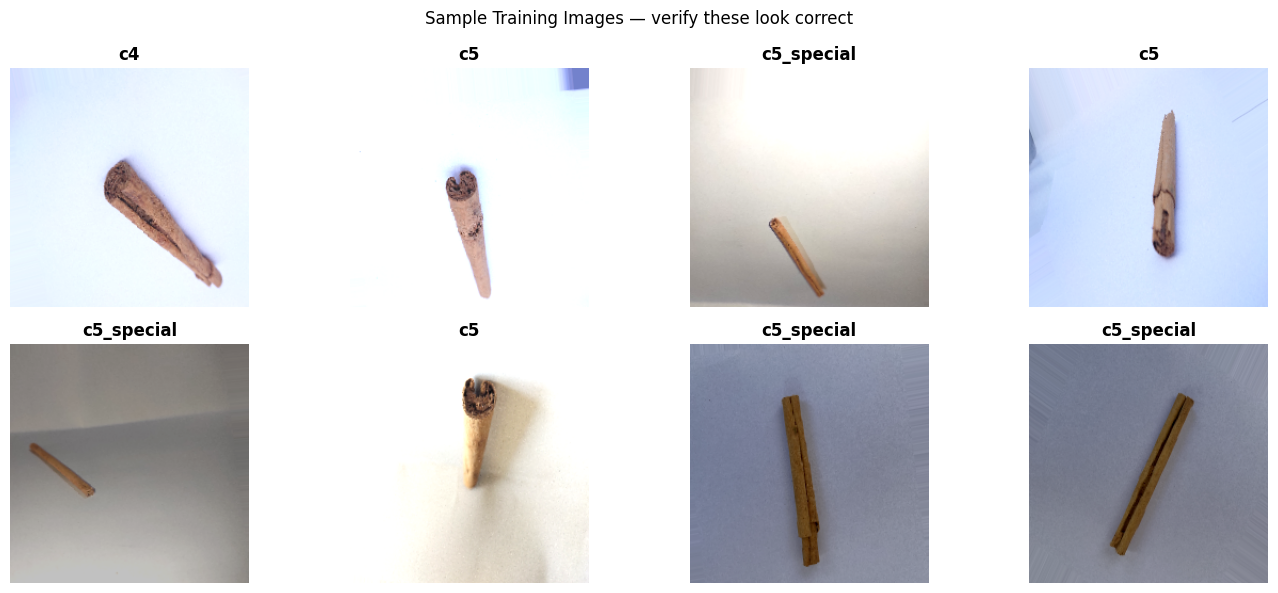

✅ Generators ready — check the images above look correct before training!


In [ ]:
# Generators + class weights:

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_gen    = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20.0,
    fill_mode='nearest'
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=True, seed=42
)
val_data = val_test_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'val'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=False
)
test_data = val_test_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'test'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=False
)

cw_array     = compute_class_weight('balanced',
                   classes=np.unique(train_data.classes),
                   y=train_data.classes)
class_weights = dict(enumerate(cw_array))

print(f'Train: {train_data.samples}  Val: {val_data.samples}  Test: {test_data.samples}')
print(f'Classes: {train_data.class_indices}')
print('\nClass weights:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:<14}: {cw_array[i]:.3f}')

# Sanity check — show sample images
imgs, lbls = next(iter(train_data))
fig, axes  = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.set_title(CLASSES[np.argmax(lbls[i])], fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Training Images — verify these look correct', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=100)
plt.show()
print('✅ Generators ready — check the images above look correct before training!')

In [ ]:
from tensorflow.keras.applications import DenseNet121, ResNet50V2, MobileNetV3Small, InceptionV3
from sklearn.metrics import accuracy_score
import gc

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
results    = {}

def build_model(base_fn, name, input_shape=(*IMG_SIZE, 3)):
    base           = base_fn(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False
    inputs  = tf.keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    model   = models.Model(inputs, outputs)
    print(f'✅ {name} built — {model.count_params():,} parameters')
    return model, base

def train_model(model, base, name, phase1_epochs=10, phase2_epochs=20, finetune_pct=0.4):
    cb = [
        EarlyStopping(monitor='val_accuracy', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{SAVE_DIR}/best_{name}.h5',
                        monitor='val_accuracy', save_best_only=True, verbose=1)
    ]
    print(f'\n{"="*50}')
    print(f'TRAINING: {name}')
    print(f'{"="*50}')
    print(f'--- Phase 1: Training head ({phase1_epochs} epochs) ---')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    h1 = model.fit(train_data, epochs=phase1_epochs,
                   validation_data=val_data,
                   class_weight=class_weights, callbacks=cb, verbose=1)

    print(f'\nBest val accuracy Phase 1: {max(h1.history["val_accuracy"]):.4f}')
    print(f'\n--- Phase 2: Fine-tuning top {int(finetune_pct*100)}% layers ---')
    base.trainable = True
    freeze_until   = int(len(base.layers) * (1 - finetune_pct))
    for layer in base.layers[:freeze_until]:
        layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    h2 = model.fit(train_data, epochs=phase2_epochs,
                   validation_data=val_data,
                   class_weight=class_weights, callbacks=cb, verbose=1)
    return h1, h2

def evaluate_model(model, name, h1, h2):
    test_data.reset()
    y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)
    y_true = test_data.classes
    labels = list(test_data.class_indices.keys())
    acc    = accuracy_score(y_true, y_pred)

    print(f'\n=== {name} Test Results ===')
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/cm_{name}.png', dpi=150)
    plt.show()

    acc_curve = h1.history['accuracy']     + h2.history['accuracy']
    val_curve = h1.history['val_accuracy'] + h2.history['val_accuracy']
    plt.figure(figsize=(9, 4))
    plt.plot(acc_curve, label='Train accuracy', color='steelblue')
    plt.plot(val_curve, label='Val accuracy',   color='orange')
    plt.axvline(x=len(h1.history['accuracy'])-1,
                color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
    plt.title(f'{name} — Training Curve', fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/curve_{name}.png', dpi=150)
    plt.show()

    results[name] = {'accuracy': acc,
                     'report':   classification_report(y_true, y_pred,
                                     target_names=labels, digits=4, output_dict=True)}
    print(f'✅ {name} — Test Accuracy: {acc*100:.2f}%')
    return acc

# Save MobileNetV2 result
results['MobileNetV2'] = {'accuracy': 0.7760}
print('✅ Setup complete — run model cells below one by one')

✅ Setup complete — run model cells below one by one


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ DenseNet121 built — 7,305,028 parameters

TRAINING: DenseNet121
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4580 - loss: 1.3866 
Epoch 1: val_accuracy improved from None to 0.47826, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 522s 15s/step - accuracy: 0.5757 - loss: 1.0653 - val_accuracy: 0.4783 - val_loss: 1.1153 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7141 - loss: 0.7845 
Epoch 2: val_accuracy improved from 0.47826 to 0.65217, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 608s 16s/step - accuracy: 0.7242 - loss: 0.7153 - val_accuracy: 0.6522 - val_loss: 0.8611 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7520 - loss: 0.6290 
Epoch 3: val_accuracy improved from 0.65217 to 0.70435, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 490s 14s/step - accuracy: 0.7577 - loss: 0.6169 - val_accuracy: 0.7043 - val_loss: 0.7631 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7873 - loss: 0.5514 
Epoch 4: val_accuracy improved from 0.70435 to 0.70870, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 508s 15s/step - accuracy: 0.7818 - loss: 0.5547 - val_accuracy: 0.7087 - val_loss: 0.7412 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8144 - loss: 0.5008 
Epoch 5: val_accuracy improved from 0.70870 to 0.72174, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5


...


Epoch 11: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 570s 17s/step - accuracy: 0.8756 - loss: 0.3264 - val_accuracy: 0.9000 - val_loss: 0.2888 - learning_rate: 1.0000e-05
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8900 - loss: 0.2952 
Epoch 12: val_accuracy improved from 0.90000 to 0.90435, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 12: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 621s 17s/step - accuracy: 0.8849 - loss: 0.3069 - val_accuracy: 0.9043 - val_loss: 0.2880 - learning_rate: 1.0000e-05
Epoch 13/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8761 - loss: 0.3349 
Epoch 13: val_accuracy did not improve from 0.90435
34/34 ━━━━━━━━━━━━━━━━━━━━ 578s 17s/step - accuracy: 0.8607 - loss: 0.3572 - val_accuracy: 0.9000 - val_loss: 0.2804 - learning_rate: 1.0000e-05
Epoch 14/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9055 - loss: 0.2767 
Epoch 14: val_accuracy did not improve from 0.90435
34/34 ━━━━━━━━━━━━━━━━━━━━ 608s 17s/step - accuracy: 0.9025 - loss: 0.2871 - val_accuracy: 0.9000 - val_loss: 0.2732 - learning_rate: 1.0000e-05
Epoch 15/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8682 - loss: 0.3412 
Epoch 15: val_accuracy improved from 0.90435 to 0.90870, saving model to /content/drive/MyDrive/cinnamon_re


Epoch 15: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 675s 18s/step - accuracy: 0.8747 - loss: 0.3308 - val_accuracy: 0.9087 - val_loss: 0.2569 - learning_rate: 1.0000e-05
Epoch 16/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9015 - loss: 0.2708 
Epoch 16: val_accuracy improved from 0.90870 to 0.91304, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 16: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 624s 18s/step - accuracy: 0.9025 - loss: 0.2693 - val_accuracy: 0.9130 - val_loss: 0.2466 - learning_rate: 1.0000e-05
Epoch 17/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8891 - loss: 0.3128 
Epoch 17: val_accuracy did not improve from 0.91304
34/34 ━━━━━━━━━━━━━━━━━━━━ 578s 17s/step - accuracy: 0.8951 - loss: 0.2865 - val_accuracy: 0.9087 - val_loss: 0.2418 - learning_rate: 1.0000e-05
Epoch 18/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9023 - loss: 0.2588 
Epoch 18: val_accuracy improved from 0.91304 to 0.92609, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 18: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 624s 18s/step - accuracy: 0.9025 - loss: 0.2594 - val_accuracy: 0.9261 - val_loss: 0.2326 - learning_rate: 1.0000e-05
Epoch 19/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8890 - loss: 0.2806 
Epoch 19: val_accuracy did not improve from 0.92609
34/34 ━━━━━━━━━━━━━━━━━━━━ 620s 18s/step - accuracy: 0.8914 - loss: 0.2805 - val_accuracy: 0.9217 - val_loss: 0.2281 - learning_rate: 1.0000e-05
Epoch 20/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8878 - loss: 0.2842 
Epoch 20: val_accuracy did not improve from 0.92609
34/34 ━━━━━━━━━━━━━━━━━━━━ 617s 18s/step - accuracy: 0.9016 - loss: 0.2678 - val_accuracy: 0.9174 - val_loss: 0.2279 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 18.

=== DenseNet121 Test Results ===
              precision    recall  f1-score   support

        alba     0.9688    0.9688    0.9688 

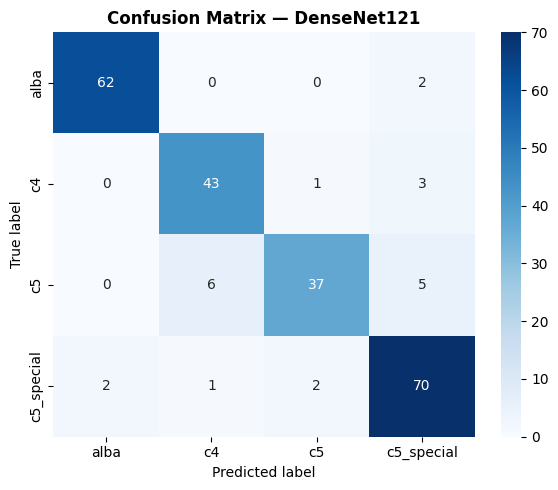

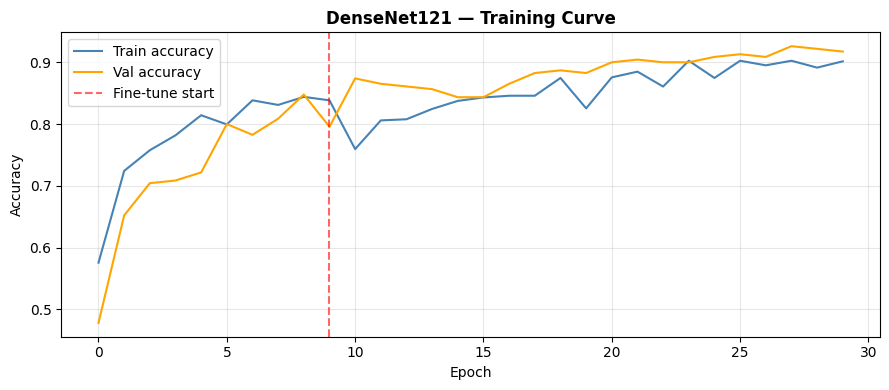

✅ DenseNet121 — Test Accuracy: 90.60%


0.905982905982906

In [ ]:
dn_model, dn_base = build_model(DenseNet121, 'DenseNet121')
dn_h1, dn_h2      = train_model(dn_model, dn_base, 'DenseNet121')
evaluate_model(dn_model, 'DenseNet121', dn_h1, dn_h2)

In [ ]:
del dn_model, dn_base
gc.collect()
tf.keras.backend.clear_session()
print('✅ Memory cleared')

✅ Memory cleared


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ ResNet50V2 built — 24,098,564 parameters

TRAINING: ResNet50V2
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4941 - loss: 1.4731 
Epoch 1: val_accuracy improved from None to 0.61304, saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 551s 16s/step - accuracy: 0.5868 - loss: 1.2692 - val_accuracy: 0.6130 - val_loss: 0.9527 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.6744 - loss: 0.9673 
Epoch 2: val_accuracy improved from 0.61304 to 0.70000, saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 554s 16s/step - accuracy: 0.7029 - loss: 0.8880 - val_accuracy: 0.7000 - val_loss: 0.7040 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7212 - loss: 0.7751 
Epoch 3: val_accuracy did not improve from 0.70000
34/34 ━━━━━━━━━━━━━━━━━━━━ 514s 15s/step - accuracy: 0.7344 - loss: 0.7538 - val_accuracy: 0.6870 - val_loss: 0.7096 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7342 - loss: 0.7673 
Epoch 4: val_accuracy improved from 0.70000 to 0.75652, saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 515s 15s/step - accuracy: 0.7419 - loss: 0.7313 - val_accuracy: 0.7565 - val_loss: 0.5155 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7644 - loss: 0.6417 
Epoch 5: val_accuracy improved from 0.75652 to 0.78696, saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5



Epoch 5: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 546s 16s/step - accuracy: 0.7725 - loss: 0.6239 - val_accuracy: 0.7870 - val_loss: 0.5652 - learning_rate: 0.0010
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7741 - loss: 0.5898 
Epoch 6: val_accuracy did not improve from 0.78696
34/34 ━━━━━━━━━━━━━━━━━━━━ 548s 16s/step - accuracy: 0.7809 - loss: 0.5956 - val_accuracy: 0.7870 - val_loss: 0.5119 - learning_rate: 0.0010
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8233 - loss: 0.4856 
Epoch 7: val_accuracy improved from 0.78696 to 0.80000, saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 687s 20s/step - accuracy: 0.7957 - loss: 0.5146 - val_accuracy: 0.8348 - val_loss: 0.3610 - learning_rate: 1.0000e-05
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8237 - loss: 0.4650 
Epoch 8: val_accuracy improved from 0.83478 to 0.84348, saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5



Epoch 8: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 715s 21s/step - accuracy: 0.8208 - loss: 0.4680 - val_accuracy: 0.8435 - val_loss: 0.3489 - learning_rate: 1.0000e-05
Epoch 9/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8408 - loss: 0.4083 
Epoch 9: val_accuracy improved from 0.84348 to 0.85217, saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5



Epoch 9: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 769s 22s/step - accuracy: 0.8301 - loss: 0.4280 - val_accuracy: 0.8522 - val_loss: 0.3443 - learning_rate: 1.0000e-05
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8333 - loss: 0.4394 
Epoch 10: val_accuracy improved from 0.85217 to 0.86957, saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5



Epoch 10: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 710s 21s/step - accuracy: 0.8366 - loss: 0.4466 - val_accuracy: 0.8696 - val_loss: 0.3315 - learning_rate: 1.0000e-05
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8323 - loss: 0.4118 
Epoch 11: val_accuracy did not improve from 0.86957
34/34 ━━━━━━━━━━━━━━━━━━━━ 712s 21s/step - accuracy: 0.8375 - loss: 0.4075 - val_accuracy: 0.8652 - val_loss: 0.3433 - learning_rate: 1.0000e-05
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.8653 - loss: 0.3760 
Epoch 12: val_accuracy did not improve from 0.86957
34/34 ━━━━━━━━━━━━━━━━━━━━ 668s 19s/step - accuracy: 0.8440 - loss: 0.3875 - val_accuracy: 0.8696 - val_loss: 0.3323 - learning_rate: 1.0000e-05
Epoch 13/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.8446 - loss: 0.3892 
Epoch 13: val_accuracy improved from 0.86957 to 0.87391, saving model to /content/drive/MyDrive/cinnamon_res


Epoch 13: finished saving model to /content/drive/MyDrive/cinnamon_results/best_ResNet50V2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 664s 19s/step - accuracy: 0.8422 - loss: 0.3900 - val_accuracy: 0.8739 - val_loss: 0.3354 - learning_rate: 1.0000e-05
Epoch 14/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.8416 - loss: 0.4068 
Epoch 14: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 14: val_accuracy did not improve from 0.87391
34/34 ━━━━━━━━━━━━━━━━━━━━ 679s 19s/step - accuracy: 0.8384 - loss: 0.4164 - val_accuracy: 0.8652 - val_loss: 0.3380 - learning_rate: 1.0000e-05
Epoch 15/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.8683 - loss: 0.3314 
Epoch 15: val_accuracy did not improve from 0.87391
34/34 ━━━━━━━━━━━━━━━━━━━━ 716s 21s/step - accuracy: 0.8607 - loss: 0.3563 - val_accuracy: 0.8522 - val_loss: 0.3377 - learning_rate: 3.0000e-06
Epoch 16/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.8527 - loss: 0.3895 
Epoch 16: val_accuracy did no

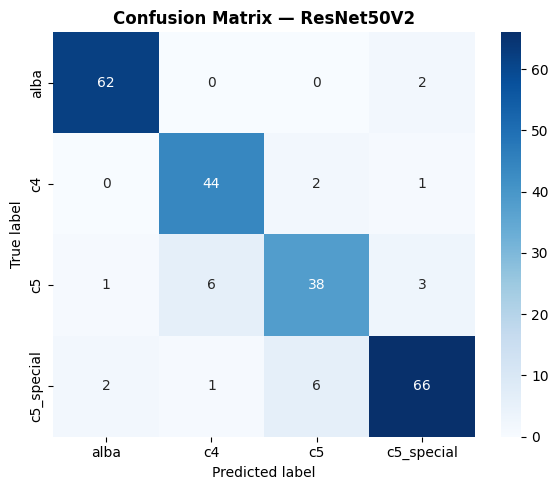

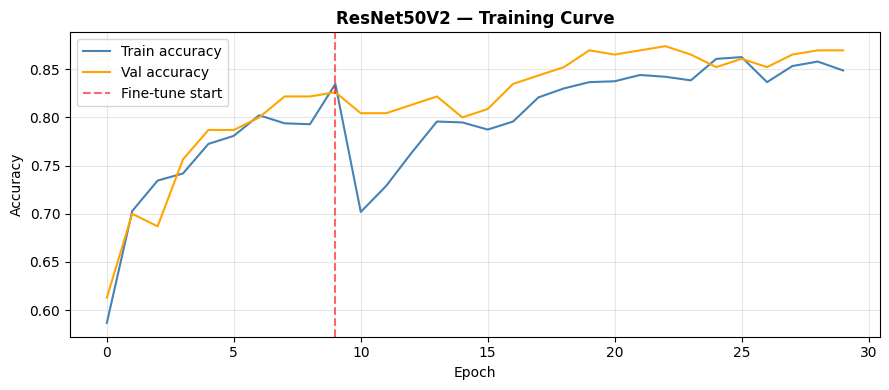

✅ ResNet50V2 — Test Accuracy: 89.74%


0.8974358974358975

In [ ]:
rn_model, rn_base = build_model(ResNet50V2, 'ResNet50V2')
rn_h1, rn_h2      = train_model(rn_model, rn_base, 'ResNet50V2')
evaluate_model(rn_model, 'ResNet50V2', rn_h1, rn_h2)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV3Small built — 1,090,164 parameters

TRAINING: MobileNetV3Small
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3717 - loss: 1.2950
Epoch 1: val_accuracy improved from None to 0.20435, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 370s 11s/step - accuracy: 0.4113 - loss: 1.2458 - val_accuracy: 0.2043 - val_loss: 1.5232 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4643 - loss: 1.1831
Epoch 2: val_accuracy improved from 0.20435 to 0.22174, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 346s 10s/step - accuracy: 0.4838 - loss: 1.1577 - val_accuracy: 0.2217 - val_loss: 1.3816 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4765 - loss: 1.1386
Epoch 3: val_accuracy did not improve from 0.22174
34/34 ━━━━━━━━━━━━━━━━━━━━ 314s 9s/step - accuracy: 0.5023 - loss: 1.1079 - val_accuracy: 0.2043 - val_loss: 1.4035 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5148 - loss: 1.0987
Epoch 4: val_accuracy improved from 0.22174 to 0.32174, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 322s 10s/step - accuracy: 0.5218 - loss: 1.0805 - val_accuracy: 0.3217 - val_loss: 1.3633 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4906 - loss: 1.1026
Epoch 5: val_accuracy did not improve from 0.32174
34/34 ━━━━━━━━━━━━━━━━━━━━ 327s 10s/step - accuracy: 0.5023 - loss: 1.0675 - val_accuracy: 0.2478 - val_loss: 1.4457 - learning_rate: 0.0010
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5355 - loss: 1.0495
Epoch 6: val_accuracy improved from 0.32174 to 0.33043, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5



Epoch 6: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 321s 10s/step - accuracy: 0.5348 - loss: 1.0292 - val_accuracy: 0.3304 - val_loss: 1.3737 - learning_rate: 0.0010
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5304 - loss: 1.0461
Epoch 7: val_accuracy improved from 0.33043 to 0.36957, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5



Epoch 7: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 303s 9s/step - accuracy: 0.5515 - loss: 1.0134 - val_accuracy: 0.3696 - val_loss: 1.3345 - learning_rate: 0.0010
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5827 - loss: 0.9708
Epoch 8: val_accuracy improved from 0.36957 to 0.40870, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5



Epoch 8: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 341s 10s/step - accuracy: 0.5617 - loss: 1.0067 - val_accuracy: 0.4087 - val_loss: 1.4137 - learning_rate: 0.0010
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5739 - loss: 0.9843
Epoch 9: val_accuracy improved from 0.40870 to 0.45217, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5



Epoch 9: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 330s 10s/step - accuracy: 0.5552 - loss: 0.9887 - val_accuracy: 0.4522 - val_loss: 1.2800 - learning_rate: 0.0010
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5541 - loss: 0.9912
Epoch 10: val_accuracy improved from 0.45217 to 0.48696, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5



Epoch 10: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV3Small.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 315s 9s/step - accuracy: 0.5627 - loss: 0.9626 - val_accuracy: 0.4870 - val_loss: 1.3184 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

Best val accuracy Phase 1: 0.4870

--- Phase 2: Fine-tuning top 40% layers ---
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2505 - loss: 5.9557
Epoch 1: val_accuracy did not improve from 0.48696
34/34 ━━━━━━━━━━━━━━━━━━━━ 353s 10s/step - accuracy: 0.2832 - loss: 5.1480 - val_accuracy: 0.3217 - val_loss: 6.5261 - learning_rate: 1.0000e-05
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3371 - loss: 3.7722
Epoch 2: val_accuracy did not improve from 0.48696
34/34 ━━━━━━━━━━━━━━━━━━━━ 332s 10s/step - accuracy: 0.3547 - loss: 3.5159 - val_accuracy: 0.3217 - val_loss: 10.7168 - learning_rate: 1.0000e-05
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


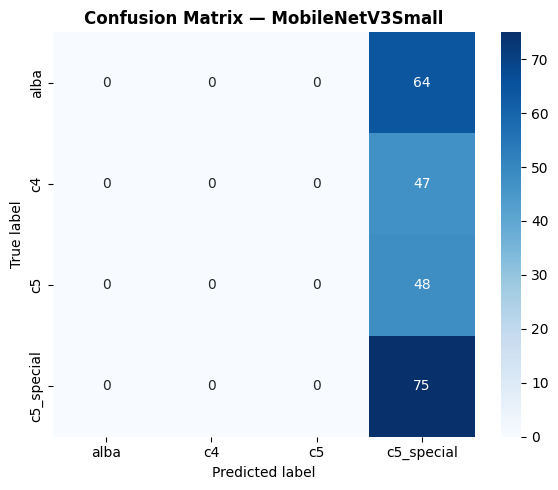

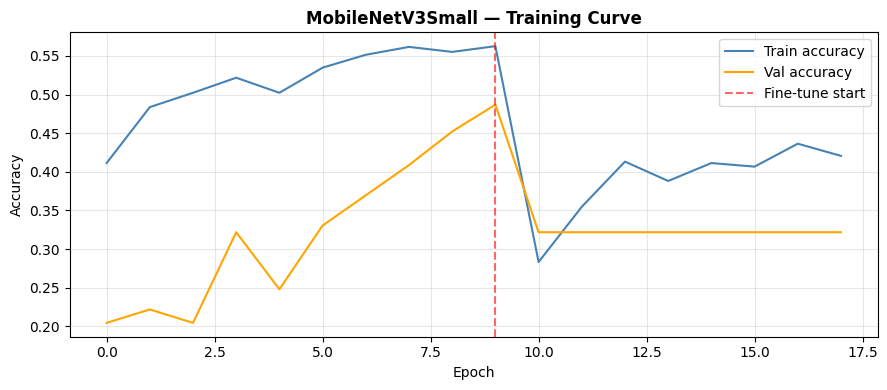

✅ MobileNetV3Small — Test Accuracy: 32.05%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.32051282051282054

In [ ]:
mv3_model, mv3_base = build_model(MobileNetV3Small, 'MobileNetV3Small')
mv3_h1, mv3_h2      = train_model(mv3_model, mv3_base, 'MobileNetV3Small')
evaluate_model(mv3_model, 'MobileNetV3Small', mv3_h1, mv3_h2)

In [ ]:
del mv3_model, mv3_base
gc.collect()
tf.keras.backend.clear_session()
print('✅ Memory cleared')

✅ Memory cleared


Found 1077 images belonging to 4 classes.
Found 230 images belonging to 4 classes.
Found 234 images belonging to 4 classes.
✅ InceptionV3 built — 22,336,548 parameters

TRAINING: InceptionV3
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5216 - loss: 1.4828 
Epoch 1: val_accuracy improved from None to 0.65652, saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 632s 18s/step - accuracy: 0.5896 - loss: 1.3411 - val_accuracy: 0.6565 - val_loss: 0.7615 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.6927 - loss: 0.9527 
Epoch 2: val_accuracy improved from 0.65652 to 0.69130, saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 582s 17s/step - accuracy: 0.7047 - loss: 0.8835 - val_accuracy: 0.6913 - val_loss: 0.7163 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7079 - loss: 0.9288 
Epoch 3: val_accuracy did not improve from 0.69130
34/34 ━━━━━━━━━━━━━━━━━━━━ 604s 18s/step - accuracy: 0.7391 - loss: 0.8154 - val_accuracy: 0.6870 - val_loss: 0.6872 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7780 - loss: 0.7280 
Epoch 4: val_accuracy improved from 0.69130 to 0.74348, saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 569s 17s/step - accuracy: 0.7614 - loss: 0.7134 - val_accuracy: 0.7435 - val_loss: 0.6688 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.7644 - loss: 0.6410 
Epoch 5: val_accuracy improved from 0.74348 to 0.78696, saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5



Epoch 5: finished saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 563s 16s/step - accuracy: 0.7734 - loss: 0.6272 - val_accuracy: 0.7870 - val_loss: 0.5441 - learning_rate: 0.0010
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8071 - loss: 0.5272 
Epoch 6: val_accuracy did not improve from 0.78696
34/34 ━━━━━━━━━━━━━━━━━━━━ 620s 18s/step - accuracy: 0.8022 - loss: 0.5416 - val_accuracy: 0.7478 - val_loss: 0.6114 - learning_rate: 0.0010
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8362 - loss: 0.4547 
Epoch 7: val_accuracy did not improve from 0.78696
34/34 ━━━━━━━━━━━━━━━━━━━━ 578s 17s/step - accuracy: 0.8245 - loss: 0.5292 - val_accuracy: 0.7826 - val_loss: 0.6273 - learning_rate: 0.0010
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.7988 - loss: 0.6104 
Epoch 8: val_accuracy improved from 0.78696 to 0.80870, saving model to /content/drive/MyDrive/cinnamon_results/best_Inceptio


Epoch 8: finished saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 576s 17s/step - accuracy: 0.8087 - loss: 0.5455 - val_accuracy: 0.8087 - val_loss: 0.5766 - learning_rate: 0.0010
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8110 - loss: 0.4985 
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 9: val_accuracy did not improve from 0.80870
34/34 ━━━━━━━━━━━━━━━━━━━━ 566s 17s/step - accuracy: 0.8180 - loss: 0.4645 - val_accuracy: 0.7870 - val_loss: 0.5741 - learning_rate: 0.0010
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8417 - loss: 0.4775 
Epoch 10: val_accuracy improved from 0.80870 to 0.81739, saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5



Epoch 10: finished saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 575s 17s/step - accuracy: 0.8468 - loss: 0.4234 - val_accuracy: 0.8174 - val_loss: 0.5005 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 10.

Best val accuracy Phase 1: 0.8174

--- Phase 2: Fine-tuning top 40% layers ---
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.7599 - loss: 0.7729 
Epoch 1: val_accuracy improved from 0.81739 to 0.84783, saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 794s 23s/step - accuracy: 0.7549 - loss: 0.7363 - val_accuracy: 0.8478 - val_loss: 0.4702 - learning_rate: 1.0000e-05
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.7991 - loss: 0.5268 
Epoch 2: val_accuracy improved from 0.84783 to 0.85217, saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_InceptionV3.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 784s 23s/step - accuracy: 0.7929 - loss: 0.5535 - val_accuracy: 0.8522 - val_loss: 0.4546 - learning_rate: 1.0000e-05
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8000 - loss: 0.5882 
Epoch 3: val_accuracy did not improve from 0.85217
34/34 ━━━━━━━━━━━━━━━━━━━━ 774s 22s/step - accuracy: 0.8087 - loss: 0.5203 - val_accuracy: 0.8261 - val_loss: 0.4993 - learning_rate: 1.0000e-05
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8101 - loss: 0.4888 
Epoch 4: val_accuracy did not improve from 0.85217
34/34 ━━━━━━━━━━━━━━━━━━━━ 744s 22s/step - accuracy: 0.8254 - loss: 0.4808 - val_accuracy: 0.8304 - val_loss: 0.5256 - learning_rate: 1.0000e-05
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8534 - loss: 0.4256 
Epoch 5: val_accuracy did not improve from 0.85217
34/34 ━━━━━━━━━━━━━━━━━━━━ 750s 22s/step - accuracy: 0.8514 - 


=== InceptionV3 Test Results ===
              precision    recall  f1-score   support

        alba     0.9677    0.9375    0.9524        64
          c4     0.7547    0.8511    0.8000        47
          c5     0.7347    0.7500    0.7423        48
  c5_special     0.9143    0.8533    0.8828        75

    accuracy                         0.8547       234
   macro avg     0.8429    0.8480    0.8444       234
weighted avg     0.8600    0.8547    0.8564       234



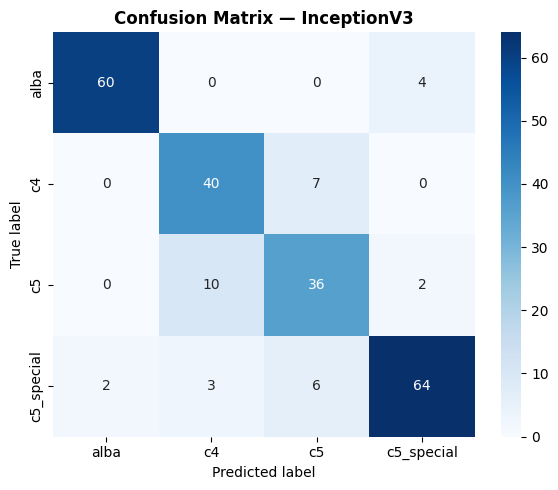

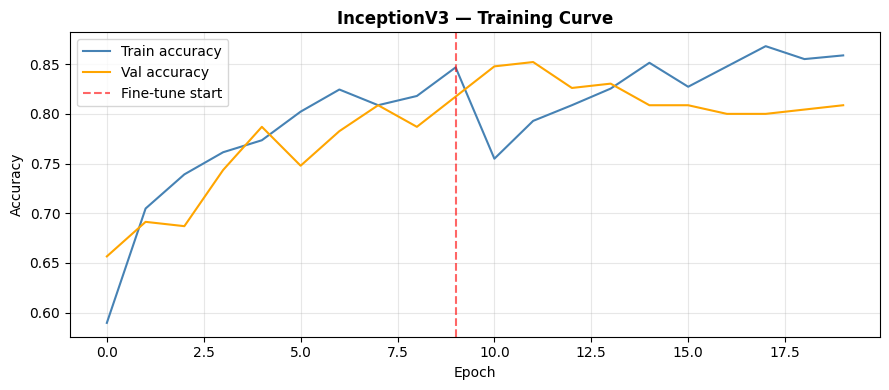

✅ InceptionV3 — Test Accuracy: 85.47%
✅ Original generators restored


In [ ]:
# InceptionV3 needs 299x299
inc_train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=30,
    width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.1, zoom_range=0.2,
    horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)
inc_val_gen = ImageDataGenerator(rescale=1./255)

inc_train = inc_train_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'train'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=True, seed=42
)
inc_val = inc_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'val'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)
inc_test = inc_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'test'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)

# Swap generators temporarily
_train, _val, _test = train_data, val_data, test_data
train_data, val_data, test_data = inc_train, inc_val, inc_test

inc_model, inc_base = build_model(InceptionV3, 'InceptionV3', input_shape=(299,299,3))
inc_h1, inc_h2      = train_model(inc_model, inc_base, 'InceptionV3')
evaluate_model(inc_model, 'InceptionV3', inc_h1, inc_h2)

# Restore original generators
train_data, val_data, test_data = _train, _val, _test
print('✅ Original generators restored')

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# EfficientNet needs its OWN preprocessing — NOT rescale=1./255
eff_train_gen = ImageDataGenerator(
    preprocessing_function=eff_preprocess,  # ← key fix
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)
eff_val_gen = ImageDataGenerator(preprocessing_function=eff_preprocess)

eff_train = eff_train_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'train'), target_size=(224,224),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=True, seed=42
)
eff_val = eff_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'val'), target_size=(224,224),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)
eff_test = eff_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'test'), target_size=(224,224),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)

# Swap generators
_train, _val, _test = train_data, val_data, test_data
train_data, val_data, test_data = eff_train, eff_val, eff_test

# Build model
base_eff = EfficientNetB0(input_shape=(224,224,3),
                           include_top=False, weights='imagenet')
base_eff.trainable = False

inputs  = tf.keras.Input(shape=(224,224,3))
x       = base_eff(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(4, activation='softmax')(x)
eff_model = models.Model(inputs, outputs)

print(f'✅ EfficientNetB0 built — {eff_model.count_params():,} parameters')

cb_eff = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f'{SAVE_DIR}/best_EfficientNetB0.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Phase 1 — longer warmup (15 epochs)
print('\n--- Phase 1: Training head (15 epochs) ---')
eff_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
eff_h1 = eff_model.fit(eff_train, epochs=15,
                        validation_data=eff_val,
                        class_weight=class_weights,
                        callbacks=cb_eff, verbose=1)

best_p1 = max(eff_h1.history['val_accuracy'])
print(f'\nBest val accuracy Phase 1: {best_p1:.4f}')

# Phase 2 — only if Phase 1 worked
if best_p1 > 0.50:
    print('\n--- Phase 2: Fine-tuning ---')
    base_eff.trainable = True
    for layer in base_eff.layers[:-30]:
        layer.trainable = False
    eff_model.compile(optimizer=tf.keras.optimizers.Adam(5e-6),
                      loss='categorical_crossentropy', metrics=['accuracy'])
    eff_h2 = eff_model.fit(eff_train, epochs=20,
                            validation_data=eff_val,
                            class_weight=class_weights,
                            callbacks=cb_eff, verbose=1)
else:
    print('⚠️  Phase 1 accuracy too low — skipping Phase 2')
    eff_h2 = eff_h1

print('\n✅ EfficientNetB0 training complete!')

Found 1077 images belonging to 4 classes.
Found 230 images belonging to 4 classes.
Found 234 images belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB0 built — 4,383,655 parameters

--- Phase 1: Training head (15 epochs) ---
Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4708 - loss: 1.5383
Epoch 1: val_accuracy improved from None to 0.53043, saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 426s 12s/step - accuracy: 0.5747 - loss: 1.2308 - val_accuracy: 0.5304 - val_loss: 0.9488 - learning_rate: 0.0010
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7352 - loss: 0.8080
Epoch 2: val_accuracy improved from 0.53043 to 0.61304, saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 383s 11s/step - accuracy: 0.7242 - loss: 0.8034 - val_accuracy: 0.6130 - val_loss: 0.8462 - learning_rate: 0.0010
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7929 - loss: 0.5904
Epoch 3: val_accuracy improved from 0.61304 to 0.66087, saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 394s 12s/step - accuracy: 0.7855 - loss: 0.6120 - val_accuracy: 0.6609 - val_loss: 0.7387 - learning_rate: 0.0010
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8202 - loss: 0.4570
Epoch 4: val_accuracy improved from 0.66087 to 0.69565, saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 385s 11s/step - accuracy: 0.7967 - loss: 0.5392 - val_accuracy: 0.6957 - val_loss: 0.6955 - learning_rate: 0.0010
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7855 - loss: 0.5486
Epoch 5: val_accuracy improved from 0.69565 to 0.71304, saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 389s 12s/step - accuracy: 0.8487 - loss: 0.4218 - val_accuracy: 0.7652 - val_loss: 0.5394 - learning_rate: 0.0010
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8563 - loss: 0.3781
Epoch 8: val_accuracy did not improve from 0.76522
34/34 ━━━━━━━━━━━━━━━━━━━━ 392s 12s/step - accuracy: 0.8459 - loss: 0.4153 - val_accuracy: 0.7087 - val_loss: 0.6611 - learning_rate: 0.0010
Epoch 9/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8319 - loss: 0.4235 
Epoch 9: val_accuracy did not improve from 0.76522
34/34 ━━━━━━━━━━━━━━━━━━━━ 390s 11s/step - accuracy: 0.8477 - loss: 0.3988 - val_accuracy: 0.7435 - val_loss: 0.5560 - learning_rate: 0.0010
Epoch 10/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8727 - loss: 0.3480
Epoch 10: val_accuracy improved from 0.76522 to 0.79130, saving model to /content/drive/MyDrive/cinnamon_results/best_Efficie


Epoch 10: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 380s 11s/step - accuracy: 0.8728 - loss: 0.3460 - val_accuracy: 0.7913 - val_loss: 0.5211 - learning_rate: 0.0010
Epoch 11/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8591 - loss: 0.3434
Epoch 11: val_accuracy did not improve from 0.79130
34/34 ━━━━━━━━━━━━━━━━━━━━ 388s 11s/step - accuracy: 0.8542 - loss: 0.3596 - val_accuracy: 0.7826 - val_loss: 0.5261 - learning_rate: 0.0010
Epoch 12/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8678 - loss: 0.3526
Epoch 12: val_accuracy improved from 0.79130 to 0.80000, saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5



Epoch 12: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 436s 11s/step - accuracy: 0.8589 - loss: 0.3654 - val_accuracy: 0.8000 - val_loss: 0.5009 - learning_rate: 0.0010
Epoch 13/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8748 - loss: 0.3087
Epoch 13: val_accuracy did not improve from 0.80000
34/34 ━━━━━━━━━━━━━━━━━━━━ 389s 11s/step - accuracy: 0.8839 - loss: 0.3001 - val_accuracy: 0.7826 - val_loss: 0.5254 - learning_rate: 0.0010
Epoch 14/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8688 - loss: 0.3178
Epoch 14: val_accuracy improved from 0.80000 to 0.83913, saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5



Epoch 14: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 381s 11s/step - accuracy: 0.8867 - loss: 0.3099 - val_accuracy: 0.8391 - val_loss: 0.3802 - learning_rate: 0.0010
Epoch 15/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8801 - loss: 0.3919
Epoch 15: val_accuracy improved from 0.83913 to 0.85217, saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5



Epoch 15: finished saving model to /content/drive/MyDrive/cinnamon_results/best_EfficientNetB0.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 380s 11s/step - accuracy: 0.8867 - loss: 0.3210 - val_accuracy: 0.8522 - val_loss: 0.4021 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 15.

Best val accuracy Phase 1: 0.8522

--- Phase 2: Fine-tuning ---
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7750 - loss: 0.6219
Epoch 1: val_accuracy did not improve from 0.85217
34/34 ━━━━━━━━━━━━━━━━━━━━ 424s 12s/step - accuracy: 0.7577 - loss: 0.6257 - val_accuracy: 0.8174 - val_loss: 0.4469 - learning_rate: 5.0000e-06
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7503 - loss: 0.6697
Epoch 2: val_accuracy did not improve from 0.85217
34/34 ━━━━━━━━━━━━━━━━━━━━ 390s 11s/step - accuracy: 0.7558 - loss: 0.6430 - val_accuracy: 0.7870 - val_loss: 0.4955 - learning_rate: 5.0000e-06
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7403 - loss

=== EfficientNetB0 Results ===
              precision    recall  f1-score   support

        alba     1.0000    0.8125    0.8966        64
          c4     0.7544    0.9149    0.8269        47
          c5     0.7600    0.7917    0.7755        48
  c5_special     0.8800    0.8800    0.8800        75

    accuracy                         0.8504       234
   macro avg     0.8486    0.8498    0.8447       234
weighted avg     0.8630    0.8504    0.8524       234



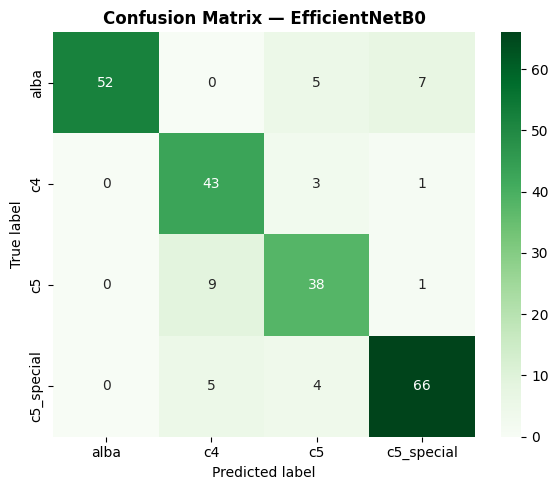

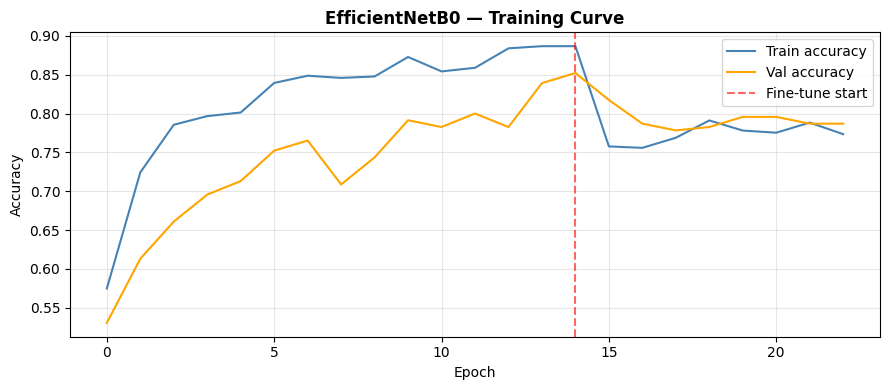


✅ EfficientNetB0 — Test Accuracy: 85.04%


In [ ]:
eff_test.reset()
y_pred_eff = np.argmax(eff_model.predict(eff_test, verbose=0), axis=1)
y_true_eff = eff_test.classes
labels     = list(eff_test.class_indices.keys())
acc_eff    = accuracy_score(y_true_eff, y_pred_eff)

print('=== EfficientNetB0 Results ===')
print(classification_report(y_true_eff, y_pred_eff, target_names=labels, digits=4))

cm = confusion_matrix(y_true_eff, y_pred_eff)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — EfficientNetB0', fontweight='bold')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_EfficientNetB0.png', dpi=150)
plt.show()

acc_curve = eff_h1.history['accuracy']     + eff_h2.history['accuracy']
val_curve = eff_h1.history['val_accuracy'] + eff_h2.history['val_accuracy']
plt.figure(figsize=(9, 4))
plt.plot(acc_curve, label='Train accuracy', color='steelblue')
plt.plot(val_curve, label='Val accuracy',   color='orange')
plt.axvline(x=len(eff_h1.history['accuracy'])-1,
            color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
plt.title('EfficientNetB0 — Training Curve', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/curve_EfficientNetB0.png', dpi=150)
plt.show()

# Restore original generators
train_data, val_data, test_data = _train, _val, _test

results['EfficientNetB0'] = {'accuracy': acc_eff}
print(f'\n✅ EfficientNetB0 — Test Accuracy: {acc_eff*100:.2f}%')

In [ ]:
del eff_model, base_eff
gc.collect()
tf.keras.backend.clear_session()
print('✅ Memory cleared')

✅ Memory cleared


In [ ]:
# Xception

from tensorflow.keras.applications import Xception

xc_model, xc_base = build_model(Xception, 'Xception', input_shape=(299,299,3))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Xception built — 21,395,244 parameters


In [ ]:
from tensorflow.keras.applications import Xception

# Xception needs 299x299 — use same inc generators
xc_train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=30,
    width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.1, zoom_range=0.2,
    horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)
xc_val_gen = ImageDataGenerator(rescale=1./255)

xc_train = xc_train_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'train'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=True, seed=42
)
xc_val = xc_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'val'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)
xc_test = xc_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'test'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)

# Swap generators
_train, _val, _test = train_data, val_data, test_data
train_data, val_data, test_data = xc_train, xc_val, xc_test

xc_model, xc_base = build_model(Xception, 'Xception', input_shape=(299,299,3))
xc_h1, xc_h2      = train_model(xc_model, xc_base, 'Xception')
evaluate_model(xc_model, 'Xception', xc_h1, xc_h2)

# Restore generators
train_data, val_data, test_data = _train, _val, _test
print('✅ Original generators restored')

Found 1077 images belonging to 4 classes.
Found 230 images belonging to 4 classes.
Found 234 images belonging to 4 classes.
✅ Xception built — 21,395,244 parameters

TRAINING: Xception
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.4455 - loss: 1.5872 
Epoch 1: val_accuracy improved from None to 0.47826, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 915s 26s/step - accuracy: 0.5590 - loss: 1.3172 - val_accuracy: 0.4783 - val_loss: 1.0368 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.7034 - loss: 0.8793 
Epoch 2: val_accuracy improved from 0.47826 to 0.64783, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 876s 26s/step - accuracy: 0.7075 - loss: 0.9305 - val_accuracy: 0.6478 - val_loss: 0.8688 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.7500 - loss: 0.7471 
Epoch 3: val_accuracy improved from 0.64783 to 0.70435, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 878s 26s/step - accuracy: 0.7530 - loss: 0.7478 - val_accuracy: 0.7043 - val_loss: 0.7677 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.7805 - loss: 0.7301 
Epoch 4: val_accuracy did not improve from 0.70435
34/34 ━━━━━━━━━━━━━━━━━━━━ 882s 26s/step - accuracy: 0.7651 - loss: 0.7066 - val_accuracy: 0.6913 - val_loss: 0.7314 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.7953 - loss: 0.5544 
Epoch 5: val_accuracy improved from 0.70435 to 0.73913, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 5: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 871s 26s/step - accuracy: 0.8013 - loss: 0.5691 - val_accuracy: 0.7391 - val_loss: 0.6784 - learning_rate: 0.0010
Epoch 6/10
 3/34 ━━━━━━━━━━━━━━━━━━━━ 12:29 24s/step - accuracy: 0.8247 - loss: 0.6309